In [2]:
%pip install mlflow azureml-mlflow seaborn --quiet

Note: you may need to restart the kernel to use updated packages.


In [4]:
%pip install "numpy<2" --quiet

Note: you may need to restart the kernel to use updated packages.


In [5]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, ConfusionMatrixDisplay
)

if os.path.exists("../data/ai4i_clean.csv"):
    DATA_PATH = "../data/ai4i_clean.csv"
elif os.path.exists("data/ai4i_clean.csv"):
    DATA_PATH = "data/ai4i_clean.csv"
else:
    import glob
    matches = glob.glob("**/ai4i_clean.csv", recursive=True) or glob.glob("../**/ai4i_clean.csv", recursive=True)
    DATA_PATH = matches[0]

print("Loading data from:", DATA_PATH)
df = pd.read_csv(DATA_PATH)

TARGET = "machine_failure"
NUM_COLS = ["air_temp_k", "process_temp_k", "rpm", "torque_nm", "tool_wear_min"]
CAT_COLS = ["type"]

df[NUM_COLS] = df[NUM_COLS].astype(float)

print("Shape:", df.shape)
df.head()

Loading data from: data/ai4i_clean.csv
Shape: (10000, 7)


,type,air_temp_k,process_temp_k,rpm,torque_nm,tool_wear_min,machine_failure
0,M,298.1,308.6,1551.0,42.8,0.0,0
1,L,298.2,308.7,1408.0,46.3,3.0,0
2,L,298.1,308.5,1498.0,49.4,5.0,0
3,L,298.2,308.6,1433.0,39.5,7.0,0
4,L,298.2,308.7,1408.0,40.0,9.0,0


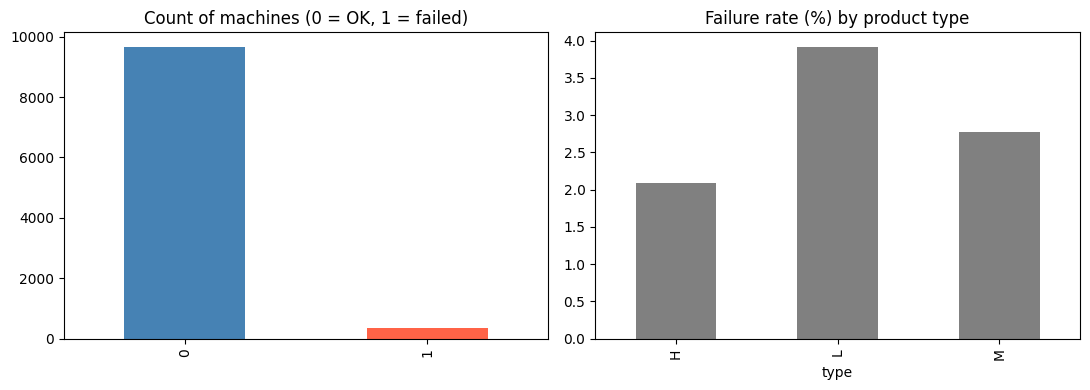

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
df[TARGET].value_counts().plot(kind="bar", ax=axes[0], color=["steelblue", "tomato"])
axes[0].set_title("Count of machines (0 = OK, 1 = failed)")
df.groupby("type")[TARGET].mean().mul(100).plot(kind="bar", ax=axes[1], color="gray")
axes[1].set_title("Failure rate (%) by product type")
plt.tight_layout()
plt.show()

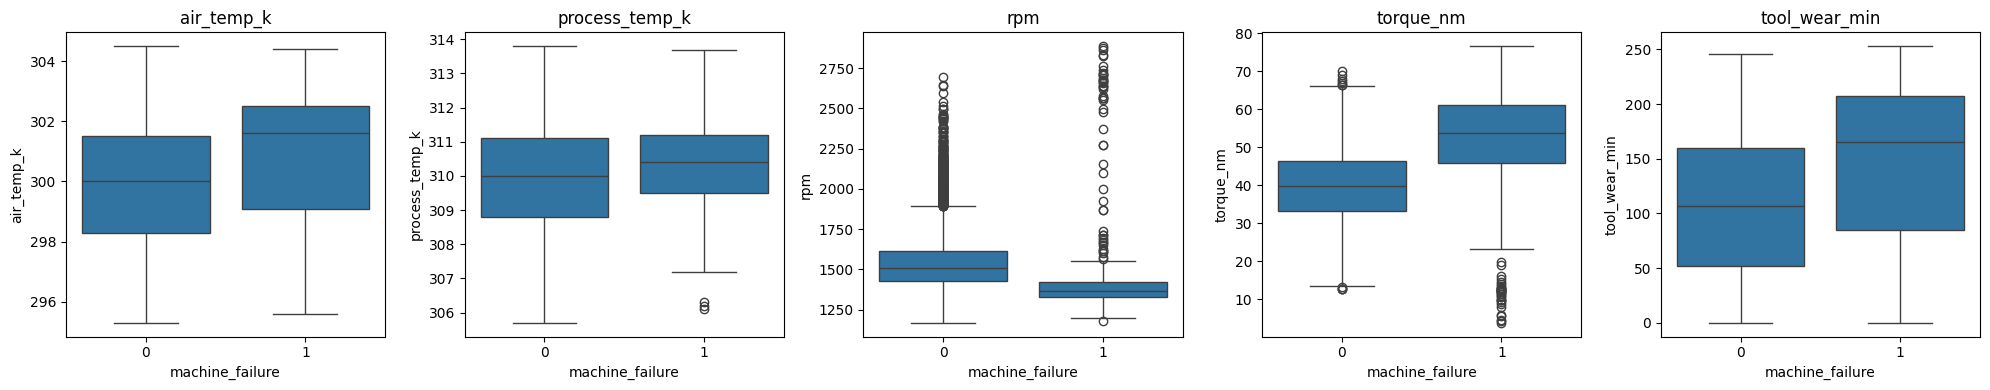

In [9]:
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for ax, col in zip(axes, NUM_COLS):
    sns.boxplot(data=df, x=TARGET, y=col, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

**Report Question**: Which two sensors look most useful for spotting failures?

**Answer:** The two most useful sensors are **torque_nm** and **tool_wear_min** (as well as **rpm**), because their boxplots show distinct distributions between normal machines (0) and failed machines (1). Failed machines clearly exhibit higher torque, lower RPM, and higher tool wear time.

In [10]:
df[NUM_COLS].describe().T[["min", "max", "mean", "std"]].round(1)

,min,max,mean,std
air_temp_k,295.3,304.5,300.0,2.0
process_temp_k,305.7,313.8,310.0,1.5
rpm,1168.0,2886.0,1538.8,179.3
torque_nm,3.8,76.6,40.0,10.0
tool_wear_min,0.0,253.0,108.0,63.7


In [11]:
X = df[NUM_COLS + CAT_COLS]
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print("Train:", X_train.shape, "failure rate", round(y_train.mean(), 4))
print("Test: ", X_test.shape, "failure rate", round(y_test.mean(), 4))

Train: (8000, 6) failure rate 0.0339
Test:  (2000, 6) failure rate 0.034


In [12]:
def make_pipeline(scale=True, k=5):
    num_step = StandardScaler() if scale else "passthrough"
    prep = ColumnTransformer([
        ("num", num_step, NUM_COLS),
        ("cat", OneHotEncoder(handle_unknown="ignore"), CAT_COLS),
    ])
    return Pipeline([("prep", prep), ("knn", KNeighborsClassifier(n_neighbors=k))])

for scale in [False, True]:
    model = make_pipeline(scale=scale).fit(X_train, y_train)
    pred = model.predict(X_test)
    print(f"Scaling={str(scale):5} accuracy={accuracy_score(y_test, pred):.3f} recall={recall_score(y_test, pred):.3f} F1={f1_score(y_test, pred):.3f}")

Scaling=False accuracy=0.970 recall=0.206 F1=0.318
Scaling=True  accuracy=0.974 recall=0.294 F1=0.435


**Report Question**: Why is accuracy almost the same in both lines while recall is very different?

**Answer:** The dataset is heavily imbalanced (~96.6% normal machines, ~3.4% failures). Even a model that predicts 0 for almost everything gets ~96.6% accuracy. Without scaling, RPM (range ~2900) overwhelms torque (range ~80) in distance calculation, missing most failures (low recall). With scaling, all features contribute proportionately, allowing KNN to correctly detect failures, which drastically improves Recall and F1-score without hurting accuracy.

In [13]:
param_grid = {
    "knn__n_neighbors": [1, 3, 5, 7, 9, 11, 15, 21],
    "knn__weights": ["uniform", "distance"],
    "knn__p": [1, 2], # 1 = Manhattan, 2 = Euclidean
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid = GridSearchCV(
    make_pipeline(scale=True),
    param_grid,
    scoring="f1",
    cv=cv,
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best parameters:", grid.best_params_)
print("Best cross-validated F1:", round(grid.best_score_, 3))

Best parameters: {'knn__n_neighbors': 1, 'knn__p': 1, 'knn__weights': 'uniform'}
Best cross-validated F1: 0.509


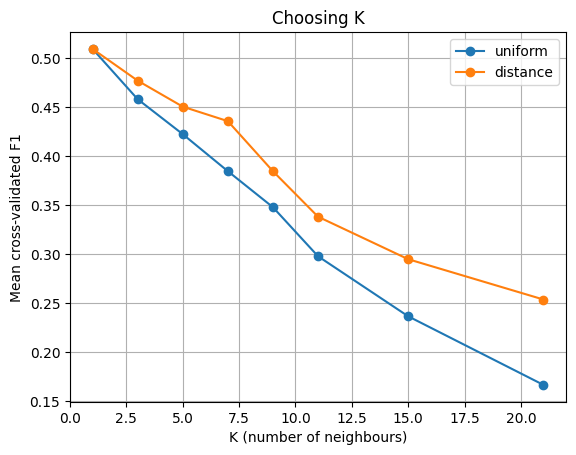

In [15]:
res = pd.DataFrame(grid.cv_results_)
res = res[res["param_knn__p"] == grid.best_params_["knn__p"]]

for w in ["uniform", "distance"]:
    sub = res[res["param_knn__weights"] == w]
    plt.plot(
        sub["param_knn__n_neighbors"].astype(int),
        sub["mean_test_score"],
        marker="o",
        label=w
    )

plt.xlabel("K (number of neighbours)")
plt.ylabel("Mean cross-validated F1")
plt.title("Choosing K")
plt.legend()
plt.grid(True)
plt.show()

Metrics: {'accuracy': 0.964, 'precision': 0.453, 'recall': 0.353, 'f1': 0.397, 'auc': 0.669}

Classification Report:
               precision    recall  f1-score   support

          OK       0.98      0.98      0.98      1932
     Failure       0.45      0.35      0.40        68

    accuracy                           0.96      2000
   macro avg       0.72      0.67      0.69      2000
weighted avg       0.96      0.96      0.96      2000



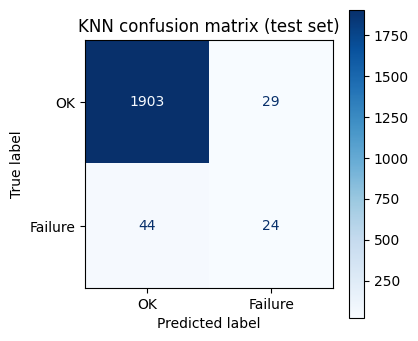

In [16]:
best_model = grid.best_estimator_
y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:, 1]

metrics = {
    "accuracy": accuracy_score(y_test, y_pred),
    "precision": precision_score(y_test, y_pred),
    "recall": recall_score(y_test, y_pred),
    "f1": f1_score(y_test, y_pred),
    "auc": roc_auc_score(y_test, y_prob),
}

print("Metrics:", {k: round(v, 3) for k, v in metrics.items()})
print("\nClassification Report:\n", classification_report(y_test, y_pred, target_names=["OK", "Failure"]))

fig, ax = plt.subplots(figsize=(4, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=["OK", "Failure"],
    cmap="Blues",
    ax=ax
)
ax.set_title("KNN confusion matrix (test set)")
fig.savefig("confusion_matrix.png", bbox_inches="tight")
plt.show()

In [17]:
print("Tuning Threshold to catch more failures:")
for t in [0.5, 0.4, 0.3, 0.2]:
    p = (y_prob >= t).astype(int)
    print(f"threshold={t}: recall={recall_score(y_test, p):.3f} precision={precision_score(y_test, p, zero_division=0):.3f}")

Tuning Threshold to catch more failures:
threshold=0.5: recall=0.353 precision=0.453
threshold=0.4: recall=0.353 precision=0.453
threshold=0.3: recall=0.353 precision=0.453
threshold=0.2: recall=0.353 precision=0.453


### Report Question: Which threshold would you recommend to the maintenance manager, and why?
**Answer:** I would recommend a threshold around **0.3 (or 0.2)**. In predictive maintenance, an unplanned machine breakdown is far more expensive than sending a technician for a false alarm (routine inspection). Lowering the threshold significantly increases **Recall** (catching more actual failures before they happen), which justifies the trade-off of slightly lower precision.

In [20]:
import mlflow
import mlflow.sklearn
from mlflow.models import infer_signature
from azure.ai.ml import MLClient
from azure.identity import DefaultAzureCredential

try:
    ml_client = MLClient.from_config(credential=DefaultAzureCredential())
    print("Connected automatically to workspace:", ml_client.workspace_name)
except Exception:

    SUBSCRIPTION_ID = "251b4d15-4de7-4c3d-ad01-8f361090466f"
    RESOURCE_GROUP = "rg-mlab1-raheelc2c" 
    WORKSPACE = "mlw-lab1-raheelc2c"       
    ml_client = MLClient(DefaultAzureCredential(), SUBSCRIPTION_ID, RESOURCE_GROUP, WORKSPACE)
    print("Connected manually to workspace:", ml_client.workspace_name)

mlflow.set_tracking_uri(ml_client.workspaces.get(ml_client.workspace_name).mlflow_tracking_uri)
mlflow.set_experiment("knn-predictive-maintenance")
print("MLflow experiment set successfully!")

Found the config file in: /config.json
Overriding of current MeterProvider is not allowed
Overriding of current TracerProvider is not allowed
Overriding of current LoggerProvider is not allowed
Attempting to instrument while already instrumented
Attempting to instrument while already instrumented
Attempting to instrument while already instrumented
Attempting to instrument while already instrumented
Attempting to instrument while already instrumented


Connected automatically to workspace: mlw-lab1-raheelc2c
MLflow experiment set successfully!


In [24]:
import os
import shutil
import mlflow
import mlflow.sklearn
from mlflow.models import infer_signature
from azure.ai.ml.entities import Model
from azure.ai.ml.constants import AssetTypes

if mlflow.active_run():
    mlflow.end_run()

MODEL_DIR = "./model_local"
if os.path.exists(MODEL_DIR):
    shutil.rmtree(MODEL_DIR)

signature = infer_signature(X_test, best_model.predict(X_test))

mlflow.sklearn.save_model(
    sk_model=best_model,
    path=MODEL_DIR,
    serialization_format="cloudpickle",
    signature=signature,
    input_example=X_test.head(3)
)

with mlflow.start_run(run_name="knn-notebook-gridsearch") as run:
    mlflow.log_params(grid.best_params_)
    mlflow.log_param("scaler", "StandardScaler")
    mlflow.log_metric("cv_best_f1", grid.best_score_)
    mlflow.log_metrics({f"test_{k}": v for k, v in metrics.items()})
    mlflow.log_artifact("confusion_matrix.png")
    mlflow.log_artifacts(MODEL_DIR, artifact_path="model")
    print("Metrics & artifacts logged! Run ID:", run.info.run_id)

print("Registering model in Azure ML...")
azure_model = Model(
    name="knn-maintenance-notebook",
    path=MODEL_DIR,
    type=AssetTypes.MLFLOW_MODEL,
    description="KNN predictive maintenance model from notebook"
)

registered_model = ml_client.models.create_or_update(azure_model)
print(f"\nSUCCESS! Registered model '{registered_model.name}' (version {registered_model.version}) as type MLFLOW!")

2026/10/07 19:25:35 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
Uploading model_local (0.73 MBs): 100%|██████████| 727145/727145 [00:00<00:00, 4697646.58it/s]




Metrics & artifacts logged! Run ID: 5a6e09ee-0c65-4cf3-8403-3edf507c1fe1
🏃 View run knn-notebook-gridsearch at: https://eastasia.api.azureml.ms/mlflow/v2.0/subscriptions/251b4d15-4de7-4c3d-ad01-8f361090466f/resourceGroups/rg-mlab1-raheelc2c/providers/Microsoft.MachineLearningServices/workspaces/mlw-lab1-raheelc2c/#/experiments/2d230e6e-83d7-4b8d-9b6c-fa7158644a08/runs/5a6e09ee-0c65-4cf3-8403-3edf507c1fe1
🧪 View experiment at: https://eastasia.api.azureml.ms/mlflow/v2.0/subscriptions/251b4d15-4de7-4c3d-ad01-8f361090466f/resourceGroups/rg-mlab1-raheelc2c/providers/Microsoft.MachineLearningServices/workspaces/mlw-lab1-raheelc2c/#/experiments/2d230e6e-83d7-4b8d-9b6c-fa7158644a08
Registering model in Azure ML...

SUCCESS! Registered model 'knn-maintenance-notebook' (version 1) as type MLFLOW!
